# 02 — Dense baseline

**Concept:** embed everything with one model, rank by cosine similarity. \
**Prediction:** none — this is the bar. Every method in notebooks 03–06 is measured
as a *paired difference against these exact per-query scores*.

The setup is the minimal RAG retriever: one small sentence-transformer
(`all-MiniLM-L6-v2`, 384 dims — chosen so the whole corpus embeds in under a minute
on a laptop), documents embedded as `title + text`, queries embedded with the same
model, dot product on unit vectors = cosine.

The absolute numbers don't matter much — a bigger embedder would lift them all by
roughly a constant. What matters is that the per-query scores get **saved to
`results/scores/dense.json`**, because a baseline you can't pair against is just
a number in a README.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ragexp.data import load_nfcorpus
from ragexp.embed import Embedder
from ragexp.retrieve import dense
from ragexp.runs import evaluate_run, save_scores, summarize

corpus = load_nfcorpus()
print(corpus.summary())

NFCorpus: 3633 docs, 323 queries, 12334 judgments (38.2/query), grade distribution {1: 11758, 2: 576}


In [2]:
emb = Embedder()
doc_matrix = emb.encode([d.full for d in corpus.docs])
print(f"doc matrix: {doc_matrix.shape}  (content-addressed cache: instant after first run)")

doc matrix: (3633, 384)  (content-addressed cache: instant after first run)


## Rank every judged query

`dense()` embeds the query and sorts all 3,633 docs by cosine. 323 queries, each a
single 3,633 × 384 matmul — this is why the corpus was chosen small.

In [3]:
rankings = {q.query_id: dense(q.text, corpus.doc_ids, doc_matrix, emb)
            for q in corpus.queries}
print(f"ranked {len(rankings)} queries")

ranked 323 queries


In [4]:
scores = evaluate_run(corpus, rankings, recall_ks=(10, 50), ndcg_ks=(10,))
path = save_scores("dense", scores)
summary = summarize(scores)
for m, v in summary.items():
    print(f"{m:>10}: {v:.4f}")
print(f"\nsaved per-query scores -> {path.relative_to(path.parents[2])}")

 recall@10: 0.1550
 recall@50: 0.2508
   ndcg@10: 0.3167

saved per-query scores -> results/scores/dense.json


## What the baseline actually retrieves

Numbers first, but look at one query — it keeps the failure modes concrete. Grade 2 =
directly relevant, grade 1 = marginally relevant, blank = unjudged (implicitly 0).

In [5]:
q = corpus.queries[0]
grades = corpus.qrels[q.query_id]
by_id = {d.doc_id: d for d in corpus.docs}
print(f"query: {q.text}\n")
for rank, doc_id in enumerate(rankings[q.query_id][:8], start=1):
    g = grades.get(doc_id, "")
    print(f"{rank:>2}. [grade {g or '-'}] {by_id[doc_id].title[:70]}")

query: Do Cholesterol Statin Drugs Cause Breast Cancer?

 1. [grade 1] Total Cholesterol and Cancer Risk in a Large Prospective Study in Kore
 2. [grade 2] Statin use and risk of breast cancer: a meta-analysis of observational
 3. [grade 2] Statin Use and Breast Cancer Survival: A Nationwide Cohort Study from 
 4. [grade -] Men with Low Serum Cholesterol Have a Lower Risk of High-Grade Prostat
 5. [grade 2] Statin use after diagnosis of breast cancer and survival: a population
 6. [grade 2] Long-term statin use and risk of ductal and lobular breast cancer amon
 7. [grade 1] Plant Sterols as Anticancer Nutrients: Evidence for Their Role in Brea
 8. [grade 2] Elevated Levels of Cholesterol-Rich Lipid Rafts in Cancer Cells Are Co


## The spread is the point

The mean hides how uneven retrieval difficulty is. This histogram is the reason
notebook 01 insisted on the *paired* bootstrap: per-query difficulty varies across
almost the whole [0, 1] range, and any comparison that doesn't cancel it is running
with a blunt instrument.

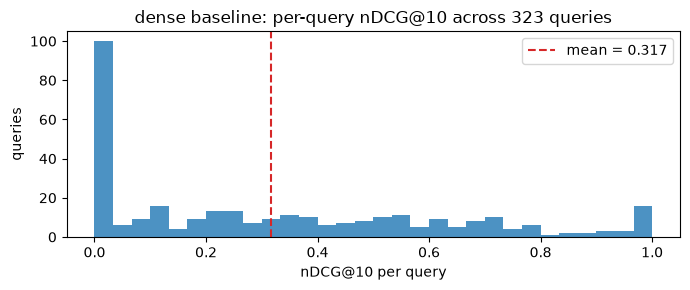

In [6]:
ndcg = [row["ndcg@10"] for row in scores.values() if row["ndcg@10"] is not None]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ndcg, bins=30, color="tab:blue", alpha=0.8)
ax.axvline(np.mean(ndcg), color="tab:red", ls="--",
           label=f"mean = {np.mean(ndcg):.3f}")
ax.set_xlabel("nDCG@10 per query")
ax.set_ylabel("queries")
ax.set_title("dense baseline: per-query nDCG@10 across 323 queries")
ax.legend()
plt.tight_layout()
plt.show()

## What goes in LESSONS.md

| what | number | verdict | lesson |
|---|---|---|---|
| dense baseline (MiniLM-L6, title+text) | see summary cell above (recall@10 / recall@50 / nDCG@10 on 323 queries) | the bar is set | a baseline is only useful if its *per-query* scores are saved — the mean alone can't be paired against |

No prediction resolved here. Next: notebook 03 asks whether BM25 and RRF fusion beat
this bar — the first genuinely open prediction in the repo.